# Assignment 05: Raster Data and Environmental Covariates

## BIO597 Spatial Analysis of Biodiversity

This assignment asks you to repeat and extend the raster workflow from Lab 05. You will clip WorldClim rasters to Maine, extract environmental values for selected amphibian occurrences, compare species, and document your predictor choices.

## Deliverable

Submit a completed notebook containing code, raster maps, an occurrence-environment table, and species summaries.

## Learning goals

By the end of this assignment, you should be able to:

* inspect raster metadata and identify alignment problems
* clip global rasters to a study-area polygon
* extract raster values at point locations
* recognize and retain NoData values
* select predictors based on ecological meaning rather than availability alone
* document a reproducible environmental-data workflow

## Data

Use:

* `Amphibians_ME/Amphibians_ME.csv` for occurrence records
* `/home/jovyan/shared-readwrite/bioclim` for WorldClim 2.1 bioclimatic rasters
* `../labs/ME_ShapeFiles/Maine_State_Boundary.shp` for the clipping boundary

The WorldClim files represent 1970–2000 climate normals at 2.5 arc-minute resolution. Variable definitions are available from the [WorldClim bioclimatic variable page](https://www.worldclim.org/data/bioclim.html).

## 1. Import packages

Import `pandas`, `geopandas`, `rioxarray`, and `xarray` using the same abbreviations as Lab 05.
Also import `Path` from the `pathlib` module as we did previously

In [1]:
pip install rioxarray

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import the four packages here.
import geopandas as gpd
import rioxarray as rxr
import xarray as xr
from pathlib import Path
import pandas as pd


## 2. Load and combine the Maine boundary

Read `Maine_State_Boundary.shp`. Inspect its CRS and shape, then use `dissolve()` to combine the polygons.

In [3]:
path = "../labs/ME_ShapeFiles/Maine_State_Boundary.shp"
maine_boundary = gpd.read_file(path)

print(maine_boundary.shape)
print(maine_boundary.crs)
# Read the boundary.
# Print its CRS and shape.
# Dissolve it to one row.
maine_boundary = maine_boundary.dissolve()

maine_boundary

(6204, 10)
EPSG:4326


,geometry,OBJECTID,LAND,GlobalID,created_us,created_da,last_edite,last_edi_1,Shape__Are,Shape__Len
0,"MULTIPOLYGON (((-70.60685 42.97751, -70.60673 ...",1,y,25ab82ef-ffa7-4098-a01a-01a5c1dfc6fc,Emily.Pettit@maine.gov_maine,2021-08-02,Emily.Pettit@maine.gov_maine,2021-08-02,8.302555e+10,5.736060e+06


## 3. Open annual mean temperature

Open `wc2.1_2.5m_bio_1.tif` with `masked=True`. Store the result as `bio1`.

In [4]:
bioclim_path = Path("/home/jovyan/shared/bioclim")
bio1_path = bioclim_path / "wc2.1_2.5m_bio_1.tif"

bio1 = rxr.open_rasterio(
    bio1_path,
    masked=True,
)

bio1

<xarray.DataArray (band: 1, y: 4320, x: 8640)> Size: 149MB
[37324800 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * x            (x) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  31.166666030884
    STATISTICS_MEAN:     nan
    STATISTICS_MINIMUM:  -54.759166717529
    STATISTICS_STDDEV:   nan
    scale_factor:        1.0
    add_offset:          0.0

## 4. Inspect annual mean temperature metadata

Report:

* dimensions and shape
* data type
* CRS
* resolution
* bounds
* NoData value

Add a brief comment beside each output explaining what it describes.

In [5]:
# Print the requested raster metadata here.
print("Dimensions:", bio1.dims) #shows dimensions (e.g. x, y, and bands)
print("Shape:", bio1.shape) #number of bands, x, and y pixels
print("Data type:", bio1.dtype) #type of point/raster data 
print("CRS:", bio1.rio.crs) #describes projection
print("Resolution:", bio1.rio.resolution()) #shows resolution
print("Bounds:", bio1.rio.bounds()) #defines lat/lon extent
print("NoData:", bio1.rio.nodata) #descriptor for N/As

Dimensions: ('band', 'y', 'x')
Shape: (1, 4320, 8640)
Data type: float32
CRS: EPSG:4326
Resolution: (0.041666666666666664, -0.041666666666666664)
Bounds: (-180.0, -89.99999999999997, 180.0, 90.0)
NoData: nan


## 5. Clip BIO1 to Maine

Use `rio.clip()` with the dissolved boundary. Set `drop=True` and `from_disk=True`, then remove the one-band dimension with `squeeze()`.

In [6]:
bio1_maine = bio1.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio1_maine = bio1_maine.squeeze()

## 6. Compare the global and clipped rasters

Display the shape, bounds, CRS, and resolution of both. State which properties changed and which remained the same.

In [7]:
# Compare global and clipped metadata here.
print("Global shape:", bio1.shape)
print("Maine shape:", bio1_maine.shape)
print("Maine bounds:", bio1_maine.rio.bounds())
print("Maine resolution:", bio1_maine.rio.resolution())

Global shape: (1, 4320, 8640)
Maine shape: (109, 101)
Maine bounds: (-71.125, 42.95833333333333, -66.91666666666667, 47.5)
Maine resolution: (0.04166666666666671, -0.041666666666666664)


**Your comparison:** the bounds and shape have changed to reflect the new extent and squeeze respectively

## 7. Plot annual mean temperature for Maine

Use the DataArray's `.plot()` method and choose an appropriate colormap.

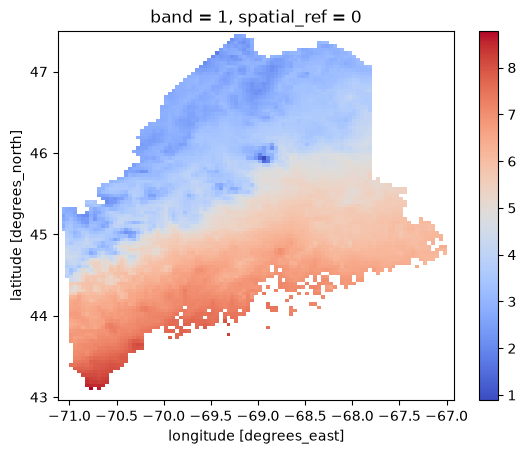

In [8]:
# Plot bio1_maine here.
bio1_maine.plot(cmap="coolwarm")

## 8. Choose three additional bioclimatic variables

Choose three variables from BIO2 through BIO19. Include at least one temperature variable and at least one precipitation variable.

Do not choose variables only because they are available. Give a short biological reason for each choice.

**Variable 1 and justification:** precip_seasonality; defines constraints for ephemeral habitat and seasonal food availability

**Variable 2 and justification:** meantemp_coldestquarter; defines the 'freeze boundary' for plants and ectotherms

**Variable 3 and justification:** precip_wettestmonth; defines constraints for species diversity (based on assumption that wetter environments have more amphibians)

## 9. Open the first additional raster

Build its filename, open it with `masked=True`, and inspect its CRS, shape, resolution, and bounds.

In [9]:
# Open your first additional raster.
bio_15 = rxr.open_rasterio(
    bioclim_path / "wc2.1_2.5m_bio_15.tif",
    masked=True,
)

# Inspect its metadata.
print("CRS:", bio_15.rio.crs) #describes projection
print("Shape", bio_15.rio.shape)
print("Resolution:", bio_15.rio.resolution()) #shows resolution
print("Bounds:", bio_15.rio.bounds()) #defines lat/lon extent
print("NoData:", bio_15.rio.nodata) #descriptor for N/As

CRS: EPSG:4326
Shape (4320, 8640)
Resolution: (0.041666666666666664, -0.041666666666666664)
Bounds: (-180.0, -89.99999999999997, 180.0, 90.0)
NoData: nan


## 10. Check alignment with BIO1

Compare CRS, shape, resolution, and bounds. Each comparison should return `True` before you treat the rasters as an aligned stack.

In [11]:
# Compare the first additional raster with bio1.
print("Same CRS:", bio1.rio.crs == bio_15.rio.crs)
print("Same shape:", bio1.shape == bio_15.shape)
print("Same resolution:", bio1.rio.resolution() == bio_15.rio.resolution())
print("Same bounds:", bio1.rio.bounds() == bio_15.rio.bounds())

Same CRS: True
Same shape: True
Same resolution: True
Same bounds: True


## 11. Clip and map the first additional raster

Use the same clipping settings as BIO1. Plot the Maine result with an appropriate colormap.

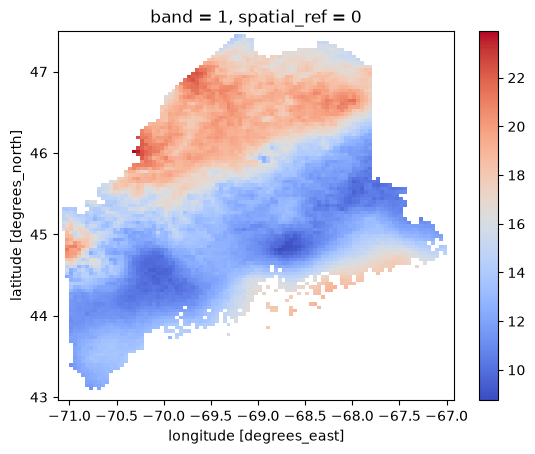

In [12]:
# Clip, squeeze, and plot the first additional raster.
bio15_maine = bio_15.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio15_maine = bio15_maine.squeeze()
bio15_maine.plot(cmap="coolwarm")

## 12. Repeat for the second additional raster

Open the raster, confirm alignment, clip it to Maine, and plot it. Keep each part of the workflow visible in your code.

Same CRS: True
Same shape: True
Same resolution: True
Same bounds: True


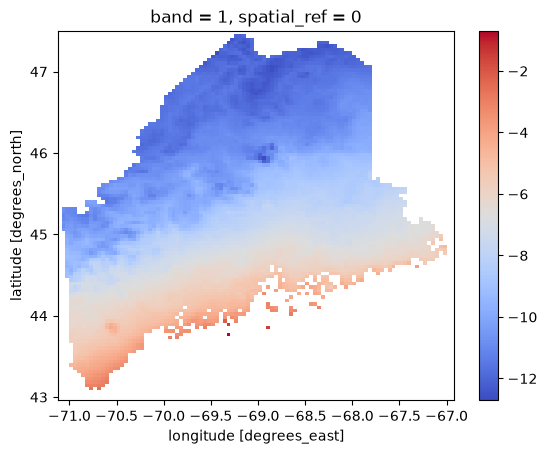

In [13]:
# Complete the workflow for the second additional raster.
bio11 = rxr.open_rasterio(
    bioclim_path / "wc2.1_2.5m_bio_11.tif",
    masked=True,
)

# Compare the first additional raster with bio1.
print("Same CRS:", bio1.rio.crs == bio11.rio.crs)
print("Same shape:", bio1.shape == bio11.shape)
print("Same resolution:", bio1.rio.resolution() == bio11.rio.resolution())
print("Same bounds:", bio1.rio.bounds() == bio11.rio.bounds())

# Clip, squeeze, and plot the raster.
bio11_maine = bio11.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio11_maine = bio11_maine.squeeze()
bio11_maine.plot(cmap="coolwarm")

## 13. Repeat for the third additional raster

Open the raster, confirm alignment, clip it to Maine, and plot it.

Same CRS: True
Same shape: True
Same resolution: True
Same bounds: True


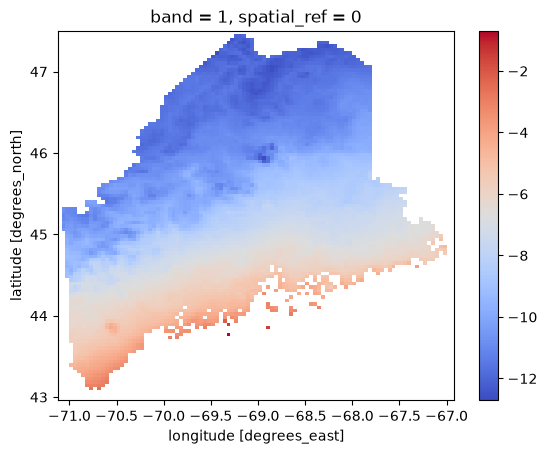

In [14]:
# Complete the workflow for the third additional raster.
bio13 = rxr.open_rasterio(
    bioclim_path / "wc2.1_2.5m_bio_11.tif",
    masked=True,
)

# Compare the  additional raster with bio1.
print("Same CRS:", bio1.rio.crs == bio13.rio.crs)
print("Same shape:", bio1.shape == bio13.shape)
print("Same resolution:", bio1.rio.resolution() == bio13.rio.resolution())
print("Same bounds:", bio1.rio.bounds() == bio13.rio.bounds())

# Clip, squeeze, and plot the raster.
bio13_maine = bio13.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio13_maine = bio13_maine.squeeze()
bio13_maine.plot(cmap="coolwarm")

## 14. Load the amphibian records

Read the tab-delimited occurrence file. Keep `gbifID`, `species`, longitude, latitude, and year.

In [15]:
amphibians = pd.read_csv(
    "Amphibians_ME/Amphibians_ME.csv",
    sep="\t",
    low_memory=False,
)

# Keep the five requested columns.
columns_to_keep = [
    "gbifID",
    "species",
    "decimalLongitude",
    "decimalLatitude",
    "year",
]

amphibians = amphibians[columns_to_keep]
amphibians.head()

,gbifID,species,decimalLongitude,decimalLatitude,year
0,6520738729,Lithobates catesbeianus,-68.660278,44.902551,2026.0
1,6520735611,Aquarana clamitans,-69.649014,44.735713,2026.0
2,6520729466,Boreorana sylvatica,-69.889241,44.798325,2026.0
3,6520721493,Lithobates palustris,-68.636788,44.860466,2022.0
4,6520718655,Lithobates pipiens,-68.788851,44.990948,2026.0


## 15. Prepare the occurrence coordinates

Convert longitude and latitude to numeric columns. Remove records missing species or coordinates.

In [16]:
# Convert both coordinate columns with pd.to_numeric().
amphibians["decimalLongitude"] = pd.to_numeric(
    amphibians["decimalLongitude"], errors="coerce"
)
amphibians["decimalLatitude"] = pd.to_numeric(
    amphibians["decimalLatitude"], errors="coerce"
)
# Drop rows missing species, longitude, or latitude.
amphibians = amphibians.dropna(
    subset=["species", "decimalLongitude", "decimalLatitude"]
).copy()

amphibians.shape

(25586, 5)

## 16. Choose three amphibian species

Inspect the species counts, then choose three species with enough records for comparison.

In [17]:
amphibians["species"].value_counts().head(20)

species
Aquarana clamitans            2966
Plethodon cinereus            2864
Pseudacris crucifer           2801
Anaxyrus americanus           2800
Boreorana sylvatica           2794
Ambystoma maculatum           2511
Lithobates catesbeianus       2302
Lithobates palustris          1626
Dryophytes versicolor         1411
Notophthalmus viridescens     1029
Lithobates pipiens             561
Eurycea bislineata             516
Hemidactylium scutatum         334
Ambystoma laterale             322
Desmognathus fuscus            215
Aquarana septentrionalis       198
Gyrinophilus porphyriticus     134
Aquarana catesbeiana            81
Rana arvalis                    54
Ambystoma jeffersonianum        37
Name: count, dtype: int64

**Species 1:** Desmognathus fuscus

**Species 2:** Plethodon cinereus
 
**Species 3:** Dryothytes versicolor

In [18]:
selected_species = [
    "Desmognathus fuscus",
    "Plethodon cinereus",
    "Dryothytes versicolor",
]

# Filter the occurrence table with .isin(selected_species).
selected_amphibians = amphibians[amphibians["species"].isin(selected_species)]
selected_amphibians.head()

,gbifID,species,decimalLongitude,decimalLatitude,year
16,6520617346,Plethodon cinereus,-70.456871,43.994310,2026.0
22,6520598054,Plethodon cinereus,-70.060469,43.835797,2026.0
43,6520421778,Plethodon cinereus,-70.926545,44.042533,2026.0
127,6519691677,Plethodon cinereus,-70.924400,44.045242,2026.0
151,6519465062,Plethodon cinereus,-69.372646,44.277734,2026.0


## 17. Create an occurrence GeoDataFrame

Use longitude and latitude to create point geometry. Assign `EPSG:4326`.

In [19]:
# Create selected_amphibians_gdf here.
selected_amphibians_gdf = gpd.GeoDataFrame(
    selected_amphibians,
    geometry=gpd.points_from_xy(
        selected_amphibians["decimalLongitude"],
        selected_amphibians["decimalLatitude"],
    ),
    crs="EPSG:4326",
)

selected_amphibians_gdf.head()

,gbifID,species,decimalLongitude,decimalLatitude,year,geometry
16,6520617346,Plethodon cinereus,-70.456871,43.994310,2026.0,POINT (-70.45687 43.99431)
22,6520598054,Plethodon cinereus,-70.060469,43.835797,2026.0,POINT (-70.06047 43.8358)
43,6520421778,Plethodon cinereus,-70.926545,44.042533,2026.0,POINT (-70.92654 44.04253)
127,6519691677,Plethodon cinereus,-70.924400,44.045242,2026.0,POINT (-70.9244 44.04524)
151,6519465062,Plethodon cinereus,-69.372646,44.277734,2026.0,POINT (-69.37265 44.27773)


## 18. Confirm coordinate systems

Print the occurrence CRS and raster CRS. Explain what must be true before extracting raster values.

In [20]:
# Print both coordinate systems.
print("Same CRS:", selected_amphibians_gdf.crs == bio1.rio.crs)


Same CRS: True


**Your explanation:**the CRS must be equal for the occurrence and raster data to be able to extract data from the raster to the gdf points

## 19. Prepare coordinates for extraction

Create `xarray.DataArray` objects called `point_x` and `point_y`. Use one dimension named `record`.

In [21]:
# Create point_x from point longitude.
# Create point_y from point latitude.
point_x = xr.DataArray(
    selected_amphibians_gdf.geometry.x.to_numpy(),
    dims="record",
)

point_y = xr.DataArray(
    selected_amphibians_gdf.geometry.y.to_numpy(),
    dims="record",
)

## 20. Extract annual mean temperature

Use `.sel()` with `x`, `y`, and `method="nearest"`. Add the extracted values to a clearly named column in the occurrence GeoDataFrame.

In [22]:
bio1_values = bio1_maine.sel(
    x=point_x,
    y=point_y,
    method="nearest",
)

# Add the values to selected_amphibians_gdf.
selected_amphibians_gdf["bio1_mean_temp_c"] = bio1_values
selected_amphibians_gdf.head()

,gbifID,species,decimalLongitude,decimalLatitude,year,geometry,bio1_mean_temp_c
16,6520617346,Plethodon cinereus,-70.456871,43.994310,2026.0,POINT (-70.45687 43.99431),6.875500
22,6520598054,Plethodon cinereus,-70.060469,43.835797,2026.0,POINT (-70.06047 43.8358),7.436167
43,6520421778,Plethodon cinereus,-70.926545,44.042533,2026.0,POINT (-70.92654 44.04253),6.673833
127,6519691677,Plethodon cinereus,-70.924400,44.045242,2026.0,POINT (-70.9244 44.04524),6.673833
151,6519465062,Plethodon cinereus,-69.372646,44.277734,2026.0,POINT (-69.37265 44.27773),6.958833


## 21. Inspect missing extracted values

Count missing BIO1 values. Explain why coastal occurrences may be assigned NoData even when the coordinates are valid.

In [23]:
# Count missing extracted BIO1 values.
selected_amphibians_gdf["bio1_mean_temp_c"].isna().value_counts()

bio1_mean_temp_c
False    2461
True      618
Name: count, dtype: int64

**Your explanation:**

## 22. Extract the three additional variables

Use the same `point_x` and `point_y` arrays. Add one clearly named column for each variable. The column names should include units where practical.

In [25]:
#15, 11, 13
# Extract values from the first additional clipped raster.
bio15_values = bio15_maine.sel(
    x=point_x,
    y=point_y,
    method="nearest",
)

# Add the values to selected_amphibians_gdf.
selected_amphibians_gdf["bio15_precip_seasonality"] = bio15_values
selected_amphibians_gdf.head()


,gbifID,species,decimalLongitude,decimalLatitude,year,geometry,bio1_mean_temp_c,bio15_precip_seasonality
16,6520617346,Plethodon cinereus,-70.456871,43.994310,2026.0,POINT (-70.45687 43.99431),6.875500,11.347319
22,6520598054,Plethodon cinereus,-70.060469,43.835797,2026.0,POINT (-70.06047 43.8358),7.436167,13.355137
43,6520421778,Plethodon cinereus,-70.926545,44.042533,2026.0,POINT (-70.92654 44.04253),6.673833,11.265086
127,6519691677,Plethodon cinereus,-70.924400,44.045242,2026.0,POINT (-70.9244 44.04524),6.673833,11.265086
151,6519465062,Plethodon cinereus,-69.372646,44.277734,2026.0,POINT (-69.37265 44.27773),6.958833,13.647320


In [26]:
# Extract values from the second additional clipped raster.
bio11_values = bio11_maine.sel(
    x=point_x,
    y=point_y,
    method="nearest",
)

# Add the values to selected_amphibians_gdf.
selected_amphibians_gdf["bio11_meantemp_coldestquarter"] = bio15_values
selected_amphibians_gdf.head()


,gbifID,species,decimalLongitude,decimalLatitude,year,geometry,bio1_mean_temp_c,bio15_precip_seasonality,bio11_meantemp_coldestquarter
16,6520617346,Plethodon cinereus,-70.456871,43.994310,2026.0,POINT (-70.45687 43.99431),6.875500,11.347319,11.347319
22,6520598054,Plethodon cinereus,-70.060469,43.835797,2026.0,POINT (-70.06047 43.8358),7.436167,13.355137,13.355137
43,6520421778,Plethodon cinereus,-70.926545,44.042533,2026.0,POINT (-70.92654 44.04253),6.673833,11.265086,11.265086
127,6519691677,Plethodon cinereus,-70.924400,44.045242,2026.0,POINT (-70.9244 44.04524),6.673833,11.265086,11.265086
151,6519465062,Plethodon cinereus,-69.372646,44.277734,2026.0,POINT (-69.37265 44.27773),6.958833,13.647320,13.647320


In [27]:
# Extract values from the third additional clipped raster.
bio13_values = bio13_maine.sel(
    x=point_x,
    y=point_y,
    method="nearest",
)

# Add the values to selected_amphibians_gdf.
selected_amphibians_gdf["bio13_precip_wettestmonth"] = bio15_values
selected_amphibians_gdf.head()


,gbifID,species,decimalLongitude,decimalLatitude,year,geometry,bio1_mean_temp_c,bio15_precip_seasonality,bio11_meantemp_coldestquarter,bio13_precip_wettestmonth
16,6520617346,Plethodon cinereus,-70.456871,43.994310,2026.0,POINT (-70.45687 43.99431),6.875500,11.347319,11.347319,11.347319
22,6520598054,Plethodon cinereus,-70.060469,43.835797,2026.0,POINT (-70.06047 43.8358),7.436167,13.355137,13.355137,13.355137
43,6520421778,Plethodon cinereus,-70.926545,44.042533,2026.0,POINT (-70.92654 44.04253),6.673833,11.265086,11.265086,11.265086
127,6519691677,Plethodon cinereus,-70.924400,44.045242,2026.0,POINT (-70.9244 44.04524),6.673833,11.265086,11.265086,11.265086
151,6519465062,Plethodon cinereus,-69.372646,44.277734,2026.0,POINT (-69.37265 44.27773),6.958833,13.647320,13.647320,13.647320


## 23. Create the occurrence-environment table

Remove the geometry column and display the first five rows. Confirm that the table contains species, coordinates, year, and four environmental variables.

In [28]:
# Create and display occurrence_environment.
occurrence_environment = selected_amphibians_gdf.drop(columns="geometry")

occurrence_environment.head()

,gbifID,species,decimalLongitude,decimalLatitude,year,bio1_mean_temp_c,bio15_precip_seasonality,bio11_meantemp_coldestquarter,bio13_precip_wettestmonth
16,6520617346,Plethodon cinereus,-70.456871,43.994310,2026.0,6.875500,11.347319,11.347319,11.347319
22,6520598054,Plethodon cinereus,-70.060469,43.835797,2026.0,7.436167,13.355137,13.355137,13.355137
43,6520421778,Plethodon cinereus,-70.926545,44.042533,2026.0,6.673833,11.265086,11.265086,11.265086
127,6519691677,Plethodon cinereus,-70.924400,44.045242,2026.0,6.673833,11.265086,11.265086,11.265086
151,6519465062,Plethodon cinereus,-69.372646,44.277734,2026.0,6.958833,13.647320,13.647320,13.647320


## 24. Summarize environmental values by species

For each selected species, calculate:

* number of records
* mean of each environmental variable
* standard deviation of each environmental variable

In [34]:
# Calculate species-level summaries here.
predictor_columns = [
    "bio1_mean_temp_c",
    "bio15_precip_seasonality",
    "bio11_meantemp_coldestquarter",
    "bio13_precip_wettestmonth",
]

for species, samples in occurrence_environment.groupby("species"):
    print(species, len(samples), "\n", samples[predictor_columns].mean(), samples[predictor_columns].std())
    

Desmognathus fuscus 215 
 bio1_mean_temp_c                  6.162017
bio15_precip_seasonality         12.245515
bio11_meantemp_coldestquarter    12.245515
bio13_precip_wettestmonth        12.245515
dtype: float64 bio1_mean_temp_c                 1.076984
bio15_precip_seasonality         2.099685
bio11_meantemp_coldestquarter    2.099685
bio13_precip_wettestmonth        2.099685
dtype: float64
Plethodon cinereus 2864 
 bio1_mean_temp_c                  6.868341
bio15_precip_seasonality         14.067693
bio11_meantemp_coldestquarter    14.067693
bio13_precip_wettestmonth        14.067693
dtype: float64 bio1_mean_temp_c                 1.040450
bio15_precip_seasonality         3.024617
bio11_meantemp_coldestquarter    3.024617
bio13_precip_wettestmonth        3.024617
dtype: float64


## 25. Check relationships among predictors

Create a correlation table for your four environmental variables. Identify any pair with a strong relationship.

In [35]:
# Select the four predictor columns and calculate .corr().
occurrence_environment[predictor_columns].corr().round(2)

,bio1_mean_temp_c,bio15_precip_seasonality,bio11_meantemp_coldestquarter,bio13_precip_wettestmonth
bio1_mean_temp_c,1.00,-0.06,-0.06,-0.06
bio15_precip_seasonality,-0.06,1.00,1.00,1.00
bio11_meantemp_coldestquarter,-0.06,1.00,1.00,1.00
bio13_precip_wettestmonth,-0.06,1.00,1.00,1.00


**Interpretation:** Which predictors contain similar information? Would you retain all of them in the same model? Explain your reasoning. All three predictors added to mean temp are correlated, which may mean that variable selection should be re-done to improve accuracy.

## 27. Save your occurrence-environment table

Save it as `Assignment05_environmental_values.csv` beside this notebook. Do not include the DataFrame index.

In [36]:
# Save occurrence_environment with .to_csv().
occurrence_environment.to_csv(
    "Assignment05_environmental_values.csv",
    index=False,
)

## Final reflection

Answer each question in two or three sentences.

1. How do raster resolution and occurrence-coordinate uncertainty interact?
A higher spatial resolution overall would depend greater on the certainty of a coordinate. Higher resolution raster data therefore should not be paired with point data that has a high degree of uncertainty. 

2. What environmental variation is lost when all occurrences in one raster cell receive the same value?
This would, I believe, depend on the values given to other raster cells, a

3. Which predictor has the strongest biological justification for your selected species?
I believe precip of the wettest month would have the strongest correlation with occurrence of amphibians. Especially for those species relying on ephemeral habitat, the precipitation of the wettest month may dictate breeding constraints. 

4. Which preprocessing choice is most important to document for reproducibility?
The choice of CRS should be documented to ensure all raster and occurrence data align. This should also be done for the resolution. 
                                                            
5. Name one additional environmental predictor you would seek for an amphibian study and explain why.
Distance from the occurrence point to a water body (if resolution allows) would be a strong predictor for amphibian habitat. This could be further expanded on by considering the size of the water body. 

## Submit your work

Run the notebook from top to bottom. Make sure all raster maps, tables, and written answers are complete. Then commit and push the completed notebook to your class GitHub repository.

```bash
git add docs/assignments/Assignment-05-RasterData.ipynb
git commit -m "Complete raster data assignment"
git push
```